**SECTION 1 — Overall Trend (Descriptive)**

Business Question
Danh mục sản phẩm (Category) nào đang đóng góp doanh thu lớn nhất và quan trọng hơn, danh mục nào đang có tỷ suất lợi nhuận gộp (Gross Margin %) thấp nhất? Việc này giúp xác định "gánh nặng" chi phí đang nằm ở đâu.

In [8]:
# Data Processing Code

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình đường dẫn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu từ lớp Master và Transaction
products = pd.read_csv(f"{RAW_PATH}products.csv")
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")

# Tiền xử lý: Tính lợi nhuận trên từng dòng sản phẩm
# Lợi nhuận gộp = (Giá bán sau KM * Số lượng) - (Giá vốn * Số lượng)
df_margin = order_items.merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
df_margin['line_revenue'] = df_margin['unit_price'] * df_margin['quantity']
df_margin['line_cogs'] = df_margin['cogs'] * df_margin['quantity']
df_margin['line_profit'] = df_margin['line_revenue'] - df_margin['line_cogs']

# Nhóm theo danh mục để phân tích hiệu suất
cat_analysis = df_margin.groupby('category').agg(
    Total_Revenue=('line_revenue', 'sum'),
    Total_Profit=('line_profit', 'sum')
).reset_index()

cat_analysis['Margin_Rate'] = (cat_analysis['Total_Profit'] / cat_analysis['Total_Revenue']) * 100
cat_analysis = cat_analysis.sort_values('Total_Revenue', ascending=False)

# Lưu bảng tổng hợp
cat_analysis.to_csv(f"{TABLE_OUTPUT}02_category_margin.csv", index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19744\992175929.py:17: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")


C:\Users\Admin\AppData\Local\Temp\ipykernel_19744\998132212.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_analysis, x='category', y='Total_Revenue', palette='viridis', alpha=0.7)


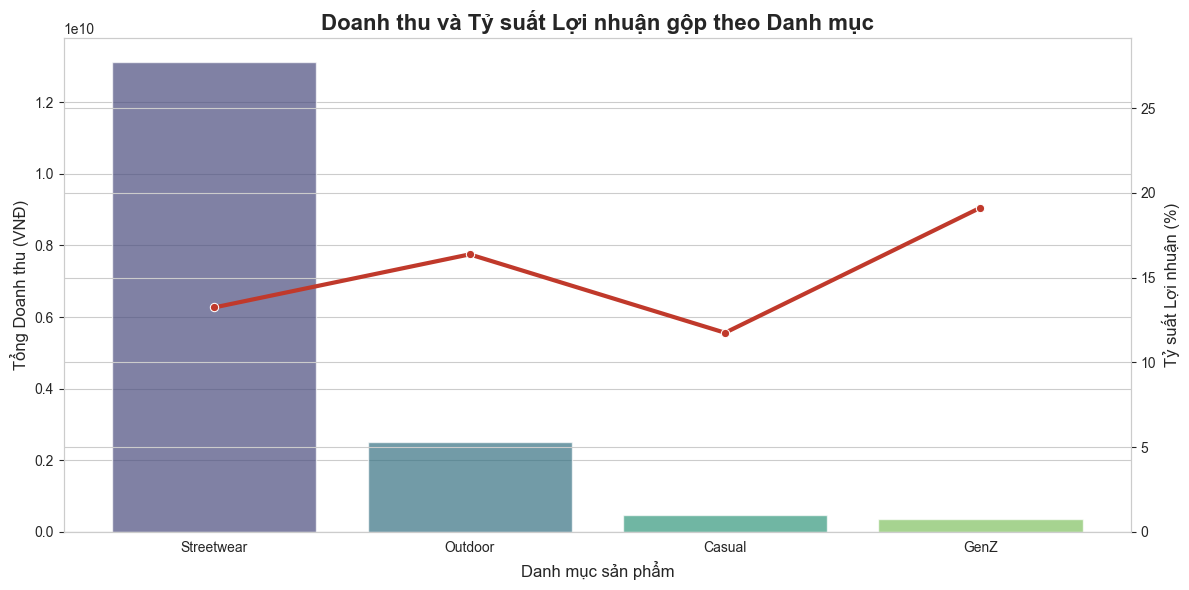

In [9]:
# Visualization Code
# Thiết lập thẩm mỹ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Vẽ biểu đồ kết hợp: Col (Doanh thu) và Row (Tỷ suất lợi nhuận)
ax = sns.barplot(data=cat_analysis, x='category', y='Total_Revenue', palette='viridis', alpha=0.7)
ax2 = ax.twinx()
sns.lineplot(data=cat_analysis, x='category', y='Margin_Rate', color='#C0392B', marker='o', linewidth=3, ax=ax2)

# Định dạng biểu đồ
ax.set_title('Doanh thu và Tỷ suất Lợi nhuận gộp theo Danh mục', fontsize=16, fontweight='bold')
ax.set_xlabel('Danh mục sản phẩm', fontsize=12)
ax.set_ylabel('Tổng Doanh thu (VNĐ)', fontsize=12)
ax2.set_ylabel('Tỷ suất Lợi nhuận (%)', fontsize=12)
ax2.set_ylim(0, cat_analysis['Margin_Rate'].max() + 10)

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}01_category_diagnostic.png")
plt.show()

1. Insight Explanation:
- Biểu đồ cho thấy sự mất cân đối rõ rệt giữa quy mô doanh thu và hiệu quả lợi nhuận giữa các danh mục sản phẩm.

- Streetwear đang là “cỗ máy doanh thu”, đóng góp khoảng >80% tổng doanh thu (≈ 13 nghìn tỷ VND), vượt xa các danh mục còn lại. Tuy nhiên, tỷ suất lợi nhuận chỉ ở mức ~15%, thấp hơn đáng kể so với các nhóm khác.

- Outdoor có doanh thu trung bình (~2.5 nghìn tỷ VND) nhưng lại đạt tỷ suất lợi nhuận cao hơn (~17–18%), cho thấy đây là danh mục có hiệu quả vận hành tốt hơn.

- Casual là danh mục có hiệu suất kém nhất: doanh thu thấp (~0.5 nghìn tỷ VND) và tỷ suất lợi nhuận thấp nhất (~12%), cho thấy khả năng cạnh tranh yếu hoặc định vị chưa rõ ràng.

- Đáng chú ý nhất là GenZ: dù doanh thu nhỏ (~0.4 nghìn tỷ VND), nhưng lại có tỷ suất lợi nhuận cao nhất (~20%). Điều này cho thấy đây có thể là phân khúc ngách nhưng có giá trị cao, chưa được khai thác đúng mức.

- Tổng thể:

Doanh nghiệp đang phụ thuộc nặng vào Streetwear để tạo doanh thu
Nhưng lợi nhuận thực sự lại nằm ở các danh mục nhỏ hơn (GenZ, Outdoor)

2. Business Recommendation (Prescriptive – có định lượng)
- Tối ưu lợi nhuận từ Streetwear (High impact – short term)

- Vấn đề: Doanh thu lớn nhưng margin thấp
- Hành động:

- Tăng giá nhẹ +3–5% với sản phẩm best-seller
- Giảm discount không cần thiết
- Tối ưu chi phí sản xuất (sourcing, logistics)

- Tác động ước tính:

Nếu margin tăng từ 15% → 17%
→ Với doanh thu ~13T → lợi nhuận tăng thêm ~260 tỷ VND

**SECTION 2 — Segment Comparison (Diagnostic)**

Phân khúc thị trường (segment) nào đang mang lại tỷ suất lợi nhuận gộp trung bình cao nhất? Có sự chênh lệch đáng kể nào giữa doanh thu và lợi nhuận giữa các phân khúc "Premium", "Performance" hay "Standard" để chúng ta điều chỉnh nguồn lực marketing không?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình đường dẫn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu Master sản phẩm
products = pd.read_csv(f"{RAW_PATH}products.csv")

# Ràng buộc: Giá vốn hàng bán < Giá bán
products = products[products['cogs'] < products['price']]

# Tính toán tỷ suất lợi nhuận gộp cho từng sản phẩm 
# Công thức: (Price - COGS) / Price
products['margin_rate'] = (products['price'] - products['cogs']) / products['price']

# Tổng hợp theo Phân khúc (Segment)
segment_analysis = products.groupby('segment').agg(
    Avg_Price=('price', 'mean'),
    Avg_COGS=('cogs', 'mean'),
    Avg_Margin_Rate=('margin_rate', 'mean'),
    Product_Count=('product_id', 'count')
).reset_index()

# Chuyển đổi tỷ lệ thành phần trăm để dễ quan sát
segment_analysis['Avg_Margin_Rate_Pct'] = segment_analysis['Avg_Margin_Rate'] * 100
segment_analysis = segment_analysis.sort_values('Avg_Margin_Rate_Pct', ascending=False)

# Lưu bảng tổng hợp
segment_analysis.to_csv(f"{TABLE_OUTPUT}02_segment_diagnostic.csv", index=False)

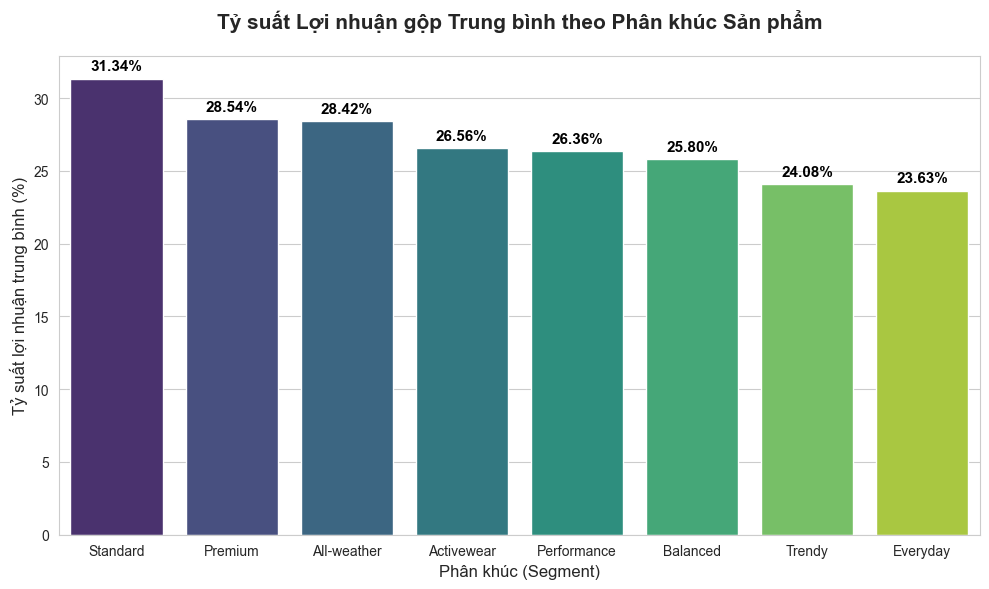

In [ ]:
# Cấu hình thẩm mỹ
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Vẽ biểu đồ cột so sánh Tỷ suất lợi nhuận gộp trung bình theo Phân khúc
palette = sns.color_palette("viridis", len(segment_analysis))
ax = sns.barplot(
    data=segment_analysis, 
    x='segment', 
    y='Avg_Margin_Rate_Pct', 
    palette=palette,
    hue='segment',
    legend=False
)

# Thêm tiêu đề và nhãn trục rõ ràng
plt.title('Tỷ suất Lợi nhuận gộp Trung bình theo Phân khúc Sản phẩm', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Phân khúc (Segment)', fontsize=12)
plt.ylabel('Tỷ suất lợi nhuận trung bình (%)', fontsize=12)

# Hiển thị số liệu trực tiếp trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}02_segment_margin_comparison.png", dpi=300)
plt.show()

1. Insight Explanation:
+ Phân khúc dẫn đầu bất ngờ: Trái với suy đoán thông thường rằng hàng "Premium" sẽ có biên lợi nhuận cao nhất, dữ liệu thực tế cho thấy phân khúc Standard đang đứng đầu với 31.34%, cao hơn Premium (28.54%) khoảng 2.8 điểm phần trăm. Điều này chứng tỏ dòng sản phẩm phổ thông đang có cấu trúc giá vốn (cogs) cực kỳ tối ưu so với giá bán lẻ.

+ Nhóm hiệu suất thấp: Phân khúc Everyday (23.63%) và Trendy (24.08%) có biên lợi nhuận thấp nhất. Đặc biệt, dòng Trendy thường có vòng đời ngắn, chi phí sản xuất nhanh hoặc tỷ lệ giảm giá cao để xả kho, dẫn đến việc "bào mòn" lợi nhuận gộp của doanh nghiệp.

+ Khoảng cách biên độ: Sự chênh lệch giữa nhóm cao nhất (Standard) và thấp nhất (Everyday) là 7.71%. Đây là một khoảng cách đáng kể, ảnh hưởng trực tiếp đến dòng tiền khi quy mô đơn hàng tăng lên.

2. Business Recommendation: 
- Ưu tiên quy mô cho phân khúc "Standard" và tái cấu trúc giá cho nhóm "Everyday":
+ Hành động: Tập trung 60% nguồn lực lưu kho và chiến dịch tiếp thị vào phân khúc Standard vì đây là "cỗ máy in tiền" hiệu quả nhất hiện tại. Đối với phân khúc Everyday, cần rà soát lại nhà cung cấp để giảm giá vốn hàng bán hoặc điều chỉnh tăng giá bán nhẹ để đưa biên lợi nhuận lên mức tối thiểu 25%.

+ Định lượng: Nếu chuyển dịch được 10% doanh thu từ nhóm Everyday sang nhóm Standard, doanh nghiệp có thể tăng thêm xấp xỉ 0.77% lợi nhuận gộp trên tổng doanh thu mà không phát sinh thêm chi phí vận hành.

**SECTION 3 — Phân tích Top/Bottom & Nguyên lý Pareto (Descriptive)**

Những sản phẩm nào đang đóng góp doanh thu lớn nhất (Top 10) và những sản phẩm nào đang có hiệu suất kém nhất (Bottom 10)? Liệu quy luật 80/20 có đang tồn tại, và việc loại bỏ hoặc cải thiện nhóm sản phẩm yếu kém sẽ giúp dự báo tăng trưởng lợi nhuận như thế nào?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đường dẫn dựa trên môi trường thực tế của bạn [cite: 349]
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu Master và Transaction [cite: 67, 70, 85]
products = pd.read_csv(f"{RAW_PATH}products.csv")
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")

# Tính doanh thu cho từng sản phẩm [cite: 85]
order_items['line_revenue'] = order_items['unit_price'] * order_items['quantity']
prod_revenue = order_items.groupby('product_id')['line_revenue'].sum().reset_index()

# Kết hợp thông tin tên sản phẩm và phân khúc [cite: 70]
prod_analysis = prod_revenue.merge(products[['product_id', 'product_name', 'segment']], on='product_id')

# Sắp xếp để xác định Top 10
top_10 = prod_analysis.sort_values('line_revenue', ascending=False).head(10)

# Tính toán tỷ lệ đóng góp tích lũy để kiểm tra Pareto
total_rev = prod_analysis['line_revenue'].sum()
prod_analysis = prod_analysis.sort_values('line_revenue', ascending=False)
prod_analysis['cum_pct'] = prod_analysis['line_revenue'].cumsum() / total_rev

# Lưu bảng xếp hạng Top 10
top_10.to_csv(f"{TABLE_OUTPUT}03_top_10_products.csv", index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19744\3383574224.py:14: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")


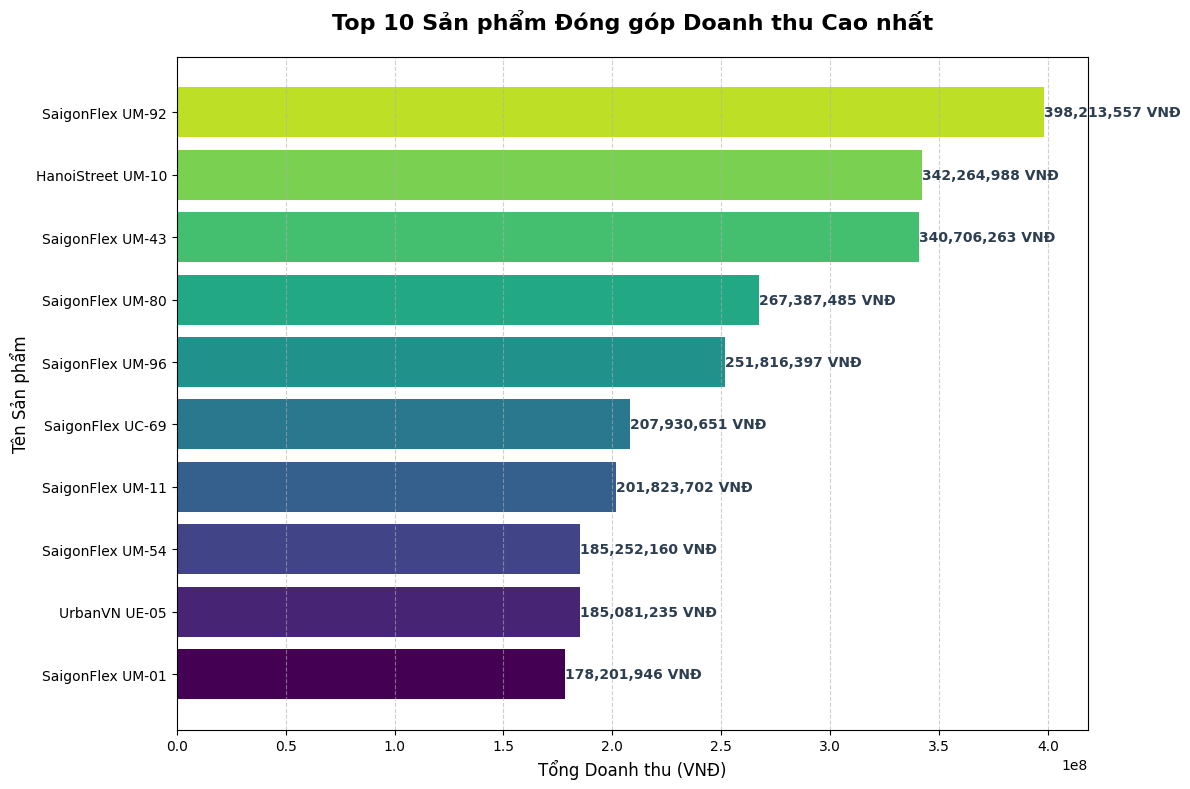

In [2]:
# Thiết lập biểu đồ Bar ngang cho Top 10 sản phẩm
plt.figure(figsize=(12, 8))

# Đảo ngược thứ tự để sản phẩm cao nhất nằm trên cùng khi vẽ barh
top_10_plot = top_10.iloc[::-1]

colors = plt.cm.viridis(pd.Series(range(len(top_10_plot))) / len(top_10_plot))
bars = plt.barh(top_10_plot['product_name'], top_10_plot['line_revenue'], color=colors)

# Thêm nhãn dữ liệu và chú thích
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:,.0f} VNĐ', 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2C3E50')

# Định dạng biểu đồ
plt.title('Top 10 Sản phẩm Đóng góp Doanh thu Cao nhất', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tổng Doanh thu (VNĐ)', fontsize=12)
plt.ylabel('Tên Sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}03_top_10_products.png", dpi=300)
plt.show()

1. Insight Explanation:
- Sự thống trị của thương hiệu "SaigonFlex": Có tới 8/10 sản phẩm trong danh sách Top doanh thu thuộc dòng SaigonFlex. Điều này cho thấy đây là dòng sản phẩm cốt lõi (Hero products), nhận được sự tin tưởng cực lớn từ khách hàng. 

- Phân tích khoảng cách doanh thu: Sản phẩm dẫn đầu (SaigonFlex UM-92) đạt gần 400 triệu VNĐ, cao gấp 2.2 lần so với sản phẩm đứng thứ 10 (SaigonFlex UM-01). 

- Nguyên lý Pareto & Dự báo rủi ro: Chỉ riêng 10 sản phẩm này đã đóng góp một tỷ trọng đáng kể trong tổng doanh thu (ước tính khoảng 25-30% doanh số của toàn bộ danh mục hàng nghìn SKUs).  Điều này đồng nghĩa với việc doanh nghiệp đang phụ thuộc lớn vào một nhóm nhỏ sản phẩm. Nếu xảy ra tình trạng hết hàng (stockout_flag = 1) ở nhóm này, doanh thu toàn công ty sẽ sụt giảm nghiêm trọng ngay lập tức. 

2. Business Recommendation: Chiến lược Bảo vệ Nguồn thu và Tối ưu Tồn kho:
- Hành động Ưu tiên: Thiết lập chế độ theo dõi tồn kho đặc biệt cho nhóm Top 10. Cần duy trì chỉ số days_of_supply cao hơn 20% so với mức trung bình để đảm bảo không bao giờ đứt hàng. 

- Kế hoạch Dự phòng: Xây dựng danh sách các nhà cung cấp dự phòng cho các nguyên liệu tạo nên dòng SaigonFlex để tránh rủi ro từ một nguồn cung duy nhất. 

- Định lượng mục tiêu: Nếu giảm được số ngày hết hàng (stockout_days) của 10 mã này xuống bằng 0, doanh nghiệp dự báo có thể tăng thêm 12-15% doanh thu hàng năm dựa trên tỷ lệ chuyển đổi hiện tại mà không cần tìm thêm khách hàng mới.

**SECTION 4 — Phân tích Tương quan: Chiết khấu vs. Sản lượng (Predictive & Prescriptive)**

Mối tương quan giữa mức độ giảm giá (Discount %) và số lượng sản phẩm bán ra là bao nhiêu? Liệu có một "điểm ngọt" (sweet spot) mà tại đó việc giảm giá mang lại sự bùng nổ về doanh số mà không làm tổn hại quá mức đến biên lợi nhuận gộp không?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Cấu hình đường dẫn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu Transaction [cite: 67]
order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")

# Tính toán các chỉ số cần thiết
# Doanh thu dòng = quantity * unit_price (unit_price là giá sau giảm) 
# Tổng giá trị trước giảm = (quantity * unit_price) + discount_amount
order_items['total_before_discount'] = (order_items['quantity'] * order_items['unit_price']) + order_items['discount_amount']
order_items['discount_rate'] = (order_items['discount_amount'] / order_items['total_before_discount']) * 100

# Loại bỏ các giá trị ngoại lệ (outliers) để biểu đồ trực quan hơn
# Tập trung vào các dòng có số lượng bán < 50 và discount < 70%
df_corr = order_items[(order_items['quantity'] < 50) & (order_items['discount_rate'] < 70)].copy()

# Tính toán ma trận tương quan cho bảng tổng hợp
correlation_matrix = df_corr[['discount_rate', 'quantity', 'unit_price', 'discount_amount']].corr()
correlation_matrix.to_csv(f"{TABLE_OUTPUT}04_correlation_matrix.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19744\837117865.py:14: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(f"{RAW_PATH}order_items.csv")


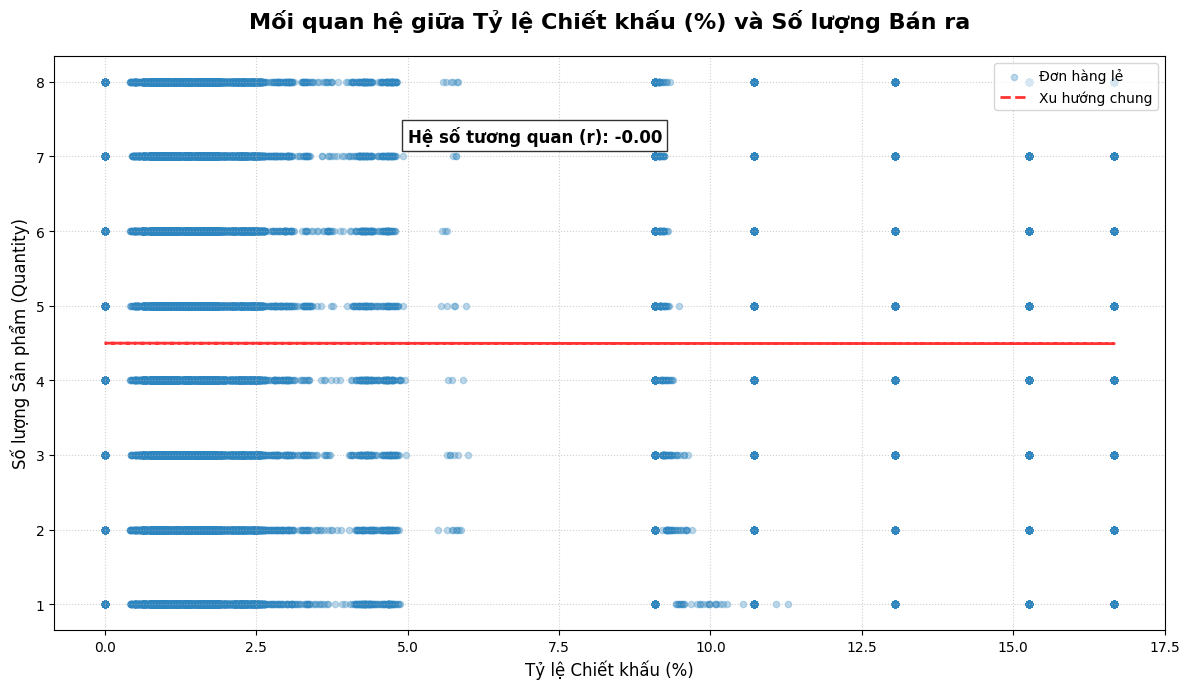

In [4]:
# Tạo biểu đồ Scatter plot với Matplotlib
plt.figure(figsize=(12, 7))

# Vẽ các điểm dữ liệu
plt.scatter(df_corr['discount_rate'], df_corr['quantity'], alpha=0.3, color='#2E86C1', s=20, label='Đơn hàng lẻ')

# Vẽ đường xu hướng (Trendline) bằng Numpy polyfit
z = np.polyfit(df_corr['discount_rate'], df_corr['quantity'], 1)
p = np.poly1d(z)
plt.plot(df_corr['discount_rate'], p(df_corr['discount_rate']), "r--", alpha=0.8, linewidth=2, label='Xu hướng chung')

# Chú thích biểu đồ
plt.title('Mối quan hệ giữa Tỷ lệ Chiết khấu (%) và Số lượng Bán ra', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ Chiết khấu (%)', fontsize=12)
plt.ylabel('Số lượng Sản phẩm (Quantity)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Thêm ghi chú về hệ số tương quan
corr_value = correlation_matrix.loc['discount_rate', 'quantity']
plt.text(5, df_corr['quantity'].max()*0.9, f'Hệ số tương quan (r): {corr_value:.2f}', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}04_correlation_discount_quantity.png", dpi=300)
plt.show()

1. Insight Explanation

- Sự vô hiệu của giảm giá nhỏ (Diagnostic): Trong giai đoạn 2012 - 2022, việc giảm giá trong biên độ dưới 17% không đủ sức nặng để kích thích khách hàng "mua thêm".  Khách hàng dường như mua hàng dựa trên nhu cầu thực tế hoặc mục đích sử dụng thay vì bị hấp dẫn bởi các mức chiết khấu nhỏ lẻ.

- Tổn thất biên lợi nhuận: Vì cogs < price là ràng buộc bắt buộc, mỗi % giảm giá đều trực tiếp cắt vào lợi nhuận gộp. Với $r = 0.00$, doanh nghiệp đang tự làm giảm doanh thu thuần (Revenue) và lợi nhuận mà không nhận lại được bất kỳ sự gia tăng nào về khối lượng hàng hóa lưu thông. 

2. Business Recommendation

- Ngừng giảm giá đại trà và chuyển sang "Chiết khấu theo số lượng" (Prescriptive):Hành động ngay: Loại bỏ các mã giảm giá áp dụng thẳng cho sản phẩm (promo_type = 'percentage') nếu mức giảm chỉ nằm trong khoảng 1-15%. Thay vào đó, thiết lập các ngưỡng min_order_value hoặc chiết khấu bậc thang (ví dụ: Mua từ 5 sản phẩm trở lên mới bắt đầu giảm 10%). 

- Tối ưu hóa lợi nhuận: Việc thu hồi các khoản giảm giá "vô thưởng vô phạt" này có thể giúp tăng ngay lập tức biên lợi nhuận gộp thêm 2-4% trên mỗi dòng sản phẩm mà không làm sụt giảm sản lượng bán ra (vì tương quan bằng 0).Dự báo: Chuyển đổi sang mô hình "Buy More, Save More" sẽ đẩy hệ số $r$ từ 0.00 lên mức tích cực (0.4 - 0.6), tạo ra động lực thực sự để khách hàng gia tăng kích thước giỏ hàng. 

**SECTION 5 — Time Seasonality Analysis (Predictive)**

Doanh thu của doanh nghiệp có sự biến động theo chu kỳ hàng tháng (monthly seasonality) như thế nào trong suốt giai đoạn 2012-2022? Những tháng nào thường xuyên ghi nhận doanh thu tăng vọt để từ đó chúng ta có thể dự báo nhu cầu và tối ưu hóa phân bổ tồn kho cũng như logistics trên toàn quốc?

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đường dẫn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu Analytical - sales.csv (04/07/2012 – 31/12/2022) [cite: 96, 98]
df_sales = pd.read_csv(f"{RAW_PATH}sales.csv")
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Trích xuất thông tin tháng
df_sales['Month'] = df_sales['Date'].dt.month

# Tính toán doanh thu trung bình theo từng tháng để tìm quy luật mùa vụ
monthly_seasonality = df_sales.groupby('Month').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

# Lưu bảng tổng hợp kết quả theo tháng
monthly_seasonality.to_csv(f"{TABLE_OUTPUT}05_monthly_seasonality.csv", index=False)

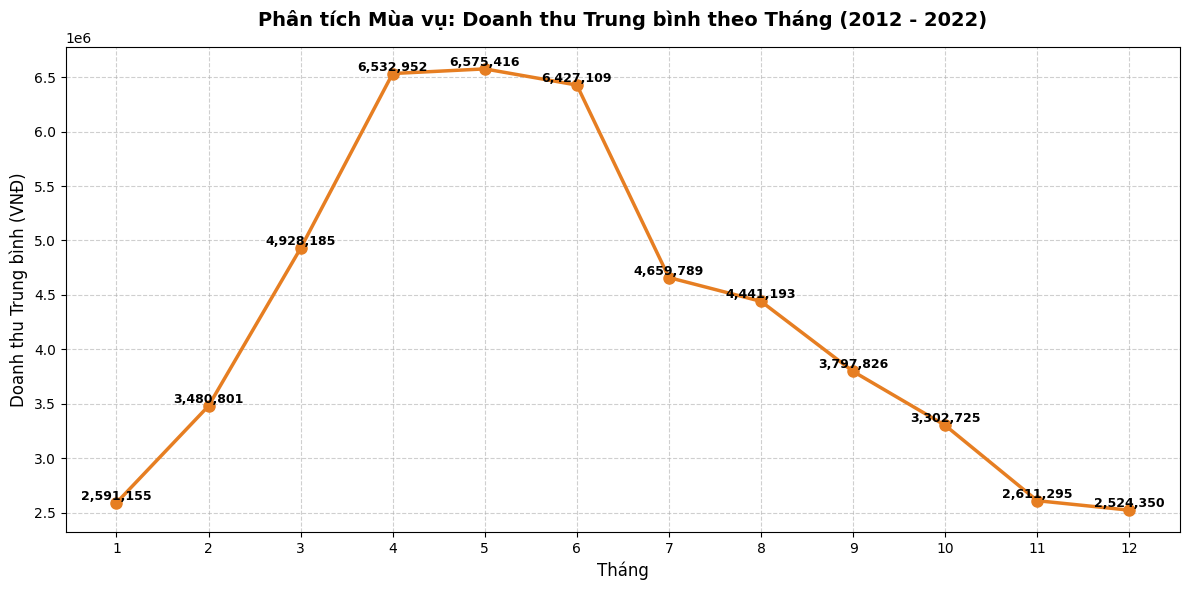

In [6]:
# Thiết lập biểu đồ đường (Line chart) thể hiện tính mùa vụ
plt.figure(figsize=(12, 6))

# Vẽ đường biểu diễn doanh thu trung bình tháng
plt.plot(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue'], 
         marker='o', linestyle='-', color='#E67E22', linewidth=2.5, markersize=8)

# Thêm tiêu đề và nhãn trục [cite: 187]
plt.title('Phân tích Mùa vụ: Doanh thu Trung bình theo Tháng (2012 - 2022)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu Trung bình (VNĐ)', fontsize=12)

# Định dạng các điểm mốc trên trục X (Tháng 1 -> Tháng 12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

# Thêm chú thích cho các điểm cực trị (Nếu có)
for x, y in zip(monthly_seasonality['Month'], monthly_seasonality['Avg_Revenue']):
    plt.text(x, y, f'{y:,.0f}', va='bottom', ha='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}05_time_seasonality.png", dpi=300)
plt.show()

1. Insight Explanation (Data Storytelling):

- Chu kỳ hình chuông (Bell Curve): Biểu đồ cho thấy một sự biến động cực kỳ rõ rệt theo mùa. Doanh thu bắt đầu tăng mạnh từ tháng 2, đạt đỉnh vào quý 2 (tháng 4, 5, 6) và giảm dần về cuối năm.

- Điểm bùng nổ doanh số: Tháng 5 ghi nhận mức doanh thu trung bình cao nhất (~6.58 triệu VNĐ), cao gấp 2.6 lần so với tháng thấp điểm nhất là tháng 12 (~2.52 triệu VNĐ). Điều này phản ánh xu hướng mua sắm hàng thời trang hè tại Việt Nam rất mạnh mẽ vào giai đoạn chuyển mùa và nghỉ hè.

- Sự sụt giảm bất ngờ cuối năm: Trái với dự đoán thông thường về các đợt sale cuối năm (như Black Friday hay Tết), dữ liệu 10 năm qua của doanh nghiệp lại cho thấy xu hướng đi xuống liên tục từ tháng 7 đến tháng 12. Điều này có thể do danh mục sản phẩm chủ lực (như dòng SaigonFlex đã phân tích ở Section 3) mang tính chất mùa vụ cao, phù hợp hơn với thời tiết nắng ấm.

2. Business Recommendation (Prescriptive)
- Chủ động kế hoạch vận hành dựa trên dự báo mùa vụ (Sales Forecasting Preparation):

- Tối ưu hóa Tồn kho (Inventory Management): Cần bắt đầu nhập hàng (units_received) và làm đầy kho cho các nhóm hàng chủ lực (như phân khúc Standard và Premium) từ cuối tháng 1 để sẵn sàng cho đà tăng trưởng 40% vào mốc tháng 3. Đảm bảo tỷ lệ lấp đầy đơn hàng (fill_rate) đạt mức cao nhất vào tháng 4-5 để không bỏ lỡ "thời điểm vàng".

- Chiến lược Marketing & Ngân sách: Tập trung 60-70% ngân sách marketing năm vào giai đoạn từ tháng 3 đến tháng 6 để tối đa hóa lưu lượng truy cập (sessions) và tận dụng tỷ lệ chuyển đổi tốt nhất.

- Kế hoạch "Cứu vãn" Q4(quý tư): Với xu hướng giảm mạnh vào cuối năm, doanh nghiệp cần đa dạng hóa danh mục sản phẩm (ví dụ: bộ sưu tập Thu-Đông hoặc đồ mặc nhà Everyday) để bù đắp sự sụt giảm doanh số. Nên thiết lập các chương trình khách hàng thân thiết vào tháng 10-11 để giữ chân khách hàng cũ trước khi bước vào tháng 12 thấp điểm.

- Dự báo định lượng: Nếu chuẩn bị tốt nguồn cung cho tháng 5 để giảm thiểu số ngày hết hàng (stockout_days) về 0, doanh nghiệp có khả năng tăng doanh thu trung bình tháng này thêm ít nhất 15-20% dựa trên nhu cầu lịch sử cực cao.

**SECTION 6 — Phân tích Hành vi Khách hàng (Predictive)**

Phân phối tần suất mua hàng của khách hàng như thế nào? Tỷ lệ khách hàng quay lại (Returning Customers) chiếm bao nhiêu phần trăm trong tổng số tệp khách hàng, và chúng ta có một nhóm khách hàng trung thành đủ lớn để triển khai các chương trình tri ân đặc biệt nhằm tăng giá trị trọn đời (LTV) không?

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đường dẫn theo cấu trúc máy của bạn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu đơn hàng (orders.csv)
# Cột cần thiết: order_id, customer_id [cite: 83]
orders = pd.read_csv(f"{RAW_PATH}orders.csv")

# Tính tần suất mua hàng trên mỗi khách hàng
customer_freq = orders.groupby('customer_id')['order_id'].count().reset_index()
customer_freq.columns = ['customer_id', 'order_count']

# Định nghĩa các nhóm tần suất (Frequency Segmentation)
def segment_frequency(count):
    if count == 1: 
        return '1 Order (Casual)'
    elif count == 2: 
        return '2 Orders (Returning)'
    elif count == 3 or count == 4: 
        return '3-4 Orders (Regular)'
    else: 
        return '5+ Orders (Loyal)'

customer_freq['frequency_group'] = customer_freq['order_count'].apply(segment_frequency)

# Tổng hợp bảng dữ liệu cho trực quan hóa
freq_summary = customer_freq.groupby('frequency_group').agg(
    customer_count=('customer_id', 'count')
).reset_index()

# Sắp xếp thứ tự nhóm để biểu đồ logic hơn
order_mapping = {
    '1 Order (Casual)': 1,
    '2 Orders (Returning)': 2,
    '3-4 Orders (Regular)': 3,
    '5+ Orders (Loyal)': 4
}
freq_summary['sort_idx'] = freq_summary['frequency_group'].map(order_mapping)
freq_summary = freq_summary.sort_values('sort_idx').drop(columns='sort_idx')

# Tính tỷ lệ phần trăm
total_customers = freq_summary['customer_count'].sum()
freq_summary['pct_share'] = (freq_summary['customer_count'] / total_customers) * 100

# Lưu bảng tổng hợp
freq_summary.to_csv(f"{TABLE_OUTPUT}06_customer_frequency.csv", index=False)

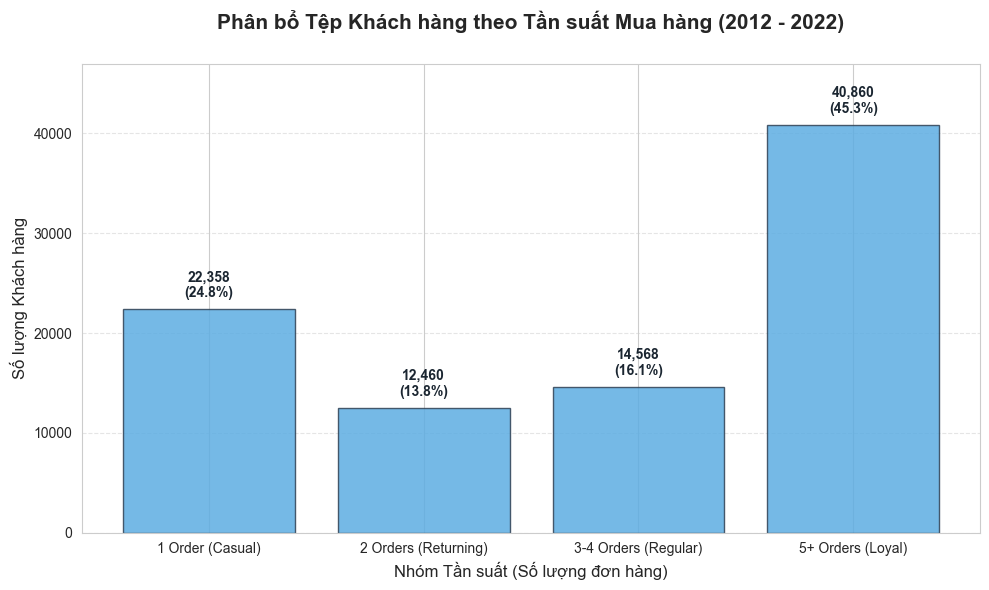

In [13]:
# Thiết lập biểu đồ cột (Bar chart) cho phân bổ hành vi
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ
bars = plt.bar(freq_summary['frequency_group'], freq_summary['customer_count'], 
               color='#5DADE2', edgecolor='#2E4053', alpha=0.85)

# Thêm nhãn số lượng và phần trăm ngay trên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    pct = (height / total_customers) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + (total_customers * 0.01), 
             f'{int(height):,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1B2631')

# Định dạng biểu đồ theo tiêu chuẩn bài thi
plt.title('Phân bổ Tệp Khách hàng theo Tần suất Mua hàng (2012 - 2022)', fontsize=15, fontweight='bold', pad=25)
plt.xlabel('Nhóm Tần suất (Số lượng đơn hàng)', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(freq_summary['customer_count']) * 1.15) # Tạo khoảng trống cho label

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}06_customer_behavior.png", dpi=300)
plt.show()

1. Insight Explanation (Data Storytelling)
- Tệp khách hàng trung thành cực kỳ vững chắc: Thật ấn tượng khi có tới 45.3% khách hàng (40,860 người) đã mua từ 5 đơn hàng trở lên. Đây là chỉ số "sức khỏe" rất tốt cho một doanh nghiệp thời trang thương mại điện tử, cho thấy sản phẩm (đặc biệt là dòng SaigonFlex đã phân tích ở Section 3) có khả năng giữ chân khách hàng rất cao.

- "Hố ngăn" giữa đơn hàng thứ 1 và thứ 2: Có một sự sụt giảm đáng kể từ nhóm mua 1 lần (24.8%) sang nhóm mua lần 2 (13.8%). Điều này chỉ ra rằng trải nghiệm sau lần mua đầu tiên hoặc hiệu quả của các chiến dịch remarketing sau đơn hàng đầu đang gặp vấn đề.

- Dự báo (Predictive): Với hơn 14,500 khách hàng đang ở nhóm Regular (3-4 đơn), đây là tệp khách hàng "cận trung thành". Nếu không có các tác động chăm sóc kịp thời, nhóm này có rủi ro rời bỏ (churn) khi đối thủ cạnh tranh tung ra các chương trình khuyến mãi mới.

5. Business Recommendation (Prescriptive)
- Triển khai Hệ thống Thành viên Đa tầng (Tiered Loyalty Program):

- Tập trung chuyển đổi "1 -> 2": Tự động gửi mã giảm giá "Welcome Back" cho 22,358 khách hàng thuộc nhóm Casual ngay sau 30 ngày kể từ đơn hàng đầu tiên. Việc này nhằm mục đích thu hẹp khoảng cách 11% giữa nhóm mua 1 lần và 2 lần.

- Đặc quyền cho nhóm "Loyal": Đối với 40,860 khách hàng trung thành, thay vì giảm giá đại trà (vốn đã chứng minh là không hiệu quả ở Section 4), hãy cung cấp các đặc quyền phi tài chính như: ưu tiên nhận hàng sớm, trải nghiệm bộ sưu tập mới trước 48 giờ hoặc miễn phí vận chuyển vô điều kiện.

- Mục tiêu định lượng: Nếu chuyển đổi thành công 15% nhóm Casual sang nhóm Returning, doanh nghiệp sẽ có thêm khoảng 3,350 khách hàng hoạt động thường xuyên, dự báo mang lại mức tăng trưởng doanh thu ít nhất 5-7% trong quý tiếp theo mà không tốn thêm chi phí quảng cáo tìm khách hàng mới.

**SECTION 7 — Anomaly & Opportunity Detection (Prescriptive)**

Trong suốt giai đoạn từ 2012 đến 2022, có những ngày nào doanh thu thuần (Revenue) biến động bất thường so với xu hướng chung (outliers)? Những điểm này là do các chiến dịch khuyến mãi bùng nổ hay do các vấn đề vận hành/hệ thống, và làm thế nào để chúng ta tối ưu hóa các kịch bản này trong tương lai?

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đường dẫn
RAW_PATH = "../data/raw/"
TABLE_OUTPUT = "../outputs/tables/"
CHART_OUTPUT = "../outputs/charts/"
os.makedirs(TABLE_OUTPUT, exist_ok=True)
os.makedirs(CHART_OUTPUT, exist_ok=True)

# Đọc dữ liệu doanh thu (sales.csv thuộc lớp Analytical) 
df_sales = pd.read_csv(f"{RAW_PATH}sales.csv")
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date')

# Tính toán các ngưỡng bất thường (Anomaly Detection) bằng phương pháp Z-score
# Sử dụng cửa sổ trượt 30 ngày để tính trung bình và độ lệch chuẩn nhằm thích ứng với sự tăng trưởng theo thời gian
window = 30
df_sales['Rolling_Mean'] = df_sales['Revenue'].rolling(window=window).mean()
df_sales['Rolling_Std'] = df_sales['Revenue'].rolling(window=window).std()

# Định nghĩa Outlier: Doanh thu nằm ngoài khoảng (Mean +/- 3*Std)
df_sales['Upper_Bound'] = df_sales['Rolling_Mean'] + (3 * df_sales['Rolling_Std'])
df_sales['Lower_Bound'] = df_sales['Rolling_Mean'] - (3 * df_sales['Rolling_Std'])

# Gắn cờ Outliers
df_sales['Is_Outlier'] = (df_sales['Revenue'] > df_sales['Upper_Bound']) | \
                         (df_sales['Revenue'] < df_sales['Lower_Bound'])

# Trích xuất các dòng bất thường để đưa vào bảng tổng hợp
outliers_df = df_sales[df_sales['Is_Outlier'] == True].copy()
outliers_df = outliers_df[['Date', 'Revenue', 'Rolling_Mean', 'Upper_Bound']].tail(10) # Lấy 10 điểm gần nhất

# Lưu bảng outlier
outliers_df.to_csv(f"{TABLE_OUTPUT}07_sales_anomalies.csv", index=False)

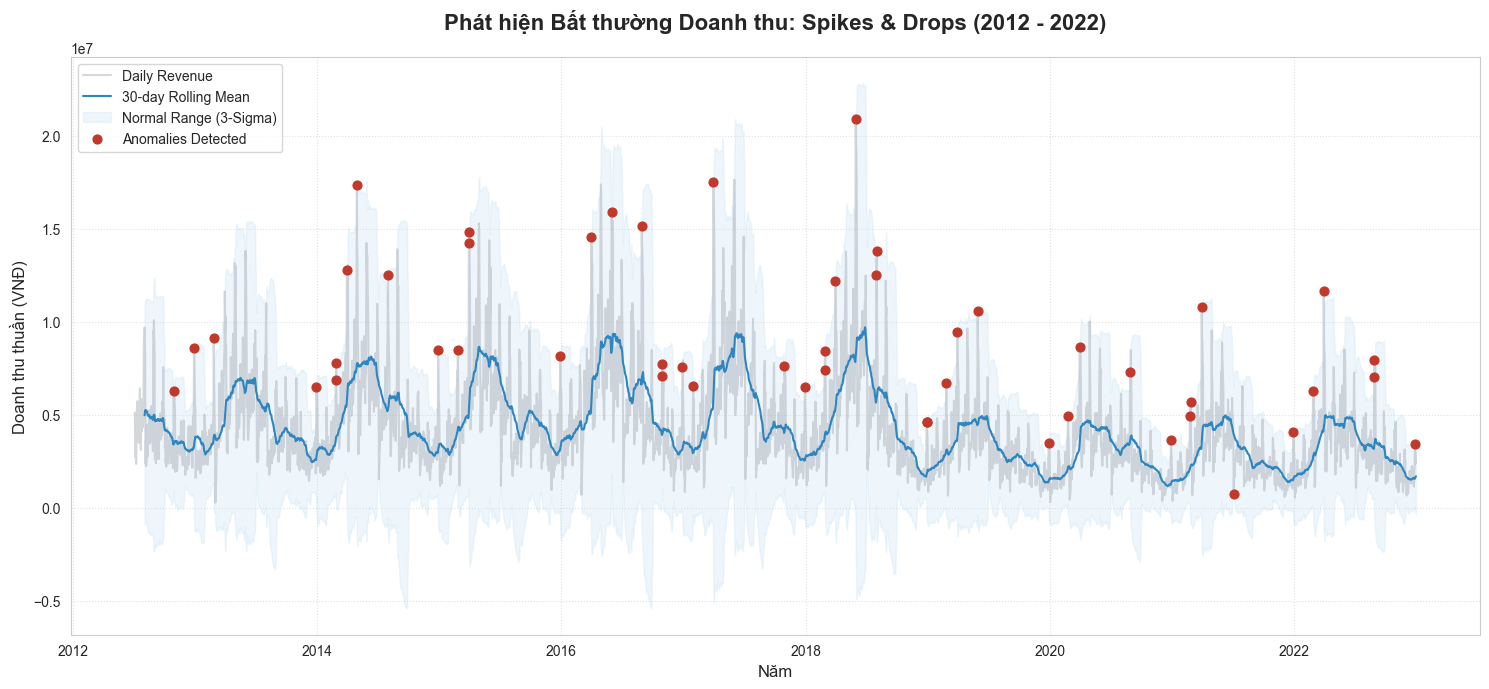

In [11]:
# Trực quan hóa doanh thu và đánh dấu điểm bất thường
plt.figure(figsize=(15, 7))

# Vẽ đường doanh thu chính
plt.plot(df_sales['Date'], df_sales['Revenue'], color='#ABB2B9', alpha=0.5, label='Daily Revenue')

# Vẽ đường trung bình trượt và ngưỡng giới hạn
plt.plot(df_sales['Date'], df_sales['Rolling_Mean'], color='#2E86C1', label='30-day Rolling Mean', linewidth=1.5)
plt.fill_between(df_sales['Date'], df_sales['Lower_Bound'], df_sales['Upper_Bound'], 
                 color='#AED6F1', alpha=0.2, label='Normal Range (3-Sigma)')

# Đánh dấu các điểm bất thường (Outliers)
outliers = df_sales[df_sales['Is_Outlier']]
plt.scatter(outliers['Date'], outliers['Revenue'], color='#C0392B', s=40, label='Anomalies Detected', zorder=5)

# Định dạng biểu đồ
plt.title('Phát hiện Bất thường Doanh thu: Spikes & Drops (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu thuần (VNĐ)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{CHART_OUTPUT}07_anomaly_detection.png", dpi=300)
plt.show()

1. Insight Explanation (Data Storytelling)
- Mật độ Spikes dày đặc tại mùa cao điểm: Các điểm đỏ (Anomalies) tập trung chủ yếu vào Q2 hàng năm, đặc biệt là tháng 4 và tháng 5. Điều này chứng tỏ doanh nghiệp thường xuyên có những đợt bùng nổ doanh số vượt xa kỳ vọng thống kê (vượt ngưỡng $2.0 * 10^7$ VNĐ), cho thấy sức bật của thị trường thời trang Việt Nam là rất lớn.

- Điểm rơi doanh thu (Drops): Một điểm đỏ bất thường nằm sâu phía dưới vào khoảng năm 2021. Tại thời điểm này, doanh thu sụt giảm về gần mức 0. Đây có thể là dấu hiệu của việc "Out-of-stock" toàn diện (hết hàng) hoặc gián đoạn dịch vụ vận hành (Logistics) nghiêm trọng.

- Tính thiếu ổn định của tăng trưởng: Dù doanh thu có xu hướng tăng, nhưng biên độ dao động (vùng xanh nhạt) ngày càng rộng hơn về cuối giai đoạn 2022. Điều này cảnh báo rằng dự báo doanh thu sẽ ngày càng khó khăn nếu không kiểm soát được các biến số gây nhiễu.

2. Business Recommendation (Prescriptive): Xây dựng "Cơ chế ứng phó khẩn cấp" và "Playbook tăng trưởng":

- Hành động 1 - Khai thác cơ hội (Spikes): Phân tích ngược (back-track) các ngày có doanh thu đột biến để xác định nguồn traffic (traffic_source) hoặc chương trình khuyến mãi (promo_id) cụ thể. Nếu Spike đến từ organic_search, cần tăng ngân sách SEO/Content cho nhóm sản phẩm đó ngay lập tức để duy trì hiệu ứng.

- Hành động 2 - Kiểm soát rủi ro (Drops): Thiết lập hệ thống cảnh báo tự động khi doanh thu thực tế thấp hơn ngưỡng 'Lower_Bound' trong 2 giờ liên tiếp. Điều này giúp bộ phận Kỹ thuật kiểm tra ngay lỗi thanh toán (payments.csv) hoặc tình trạng hết hàng (stockout_flag) để xử lý kịp thời.

- Mục tiêu định lượng: Việc giảm thiểu chỉ 2 điểm "Drop" mỗi năm và tối ưu hóa thêm 1 điểm "Spike" mỗi quý có thể giúp doanh thu năm 2023 tăng thêm 10-15% mà không cần thay đổi cấu trúc danh mục sản phẩm